In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,AgglomerativeClustering,DBSCAN
from sklearn.metrics import silhouette_score
from IPython.display import display

# =========================================================
# Section (A): Data loading and preprocessing
# =========================================================

In [20]:
df = pd.read_csv("Mall_Customers.csv")
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


remove missing values

In [25]:
df = df.dropna()

Select numeric columns 

In [28]:
numeric_features = df.select_dtypes(include=["int64", "float64"])
print("Numeric features:", numeric_features.columns)

Numeric features: Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')


In [30]:
df=numeric_features.iloc[:,1:]
df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


Apply StandardScaler 

In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Build 2D PCA for visualization

In [36]:
pca = PCA(n_components=2,random_state=53)
X_pca = pca.fit_transform(X_scaled)

In [38]:
print('PCA explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance (2D):', pca.explained_variance_ratio_.sum())

PCA explained variance ratio: [0.44266167 0.33308378]
Total explained variance (2D): 0.7757454566976746


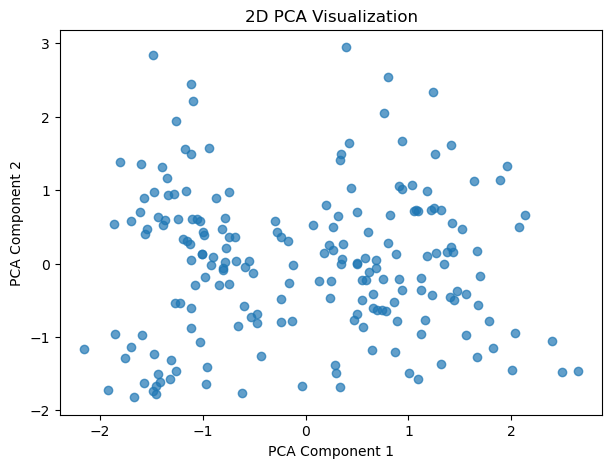

In [40]:
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("2D PCA Visualization")
plt.show()

# =========================================================
# Section (B): KMEANS ANALYSIS
# =========================================================

In [43]:
inertias = []
sil_scores = []
Ks = range(2, 11)

for k in Ks:
    km = KMeans(n_clusters=k,random_state=53,n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

In [45]:
results = pd.DataFrame({
    "K": list(Ks),
    "Inertia": inertias,
    "Silhouette": sil_scores
})
display(results)

best_k = int(results.loc[results["Silhouette"].idxmax(), "K"])
print(f"Best K by max silhouette: {best_k}")

,K,Inertia,Silhouette
0,2,389.386189,0.335472
1,3,295.456245,0.357923
2,4,205.225147,0.403958
3,5,168.247580,0.416643
4,6,133.868334,0.427428
5,7,117.169115,0.422419
6,8,103.817972,0.407788
7,9,92.293165,0.420786
8,10,81.545784,0.400985


Best K by max silhouette: 6


## Silhouette Score vs K

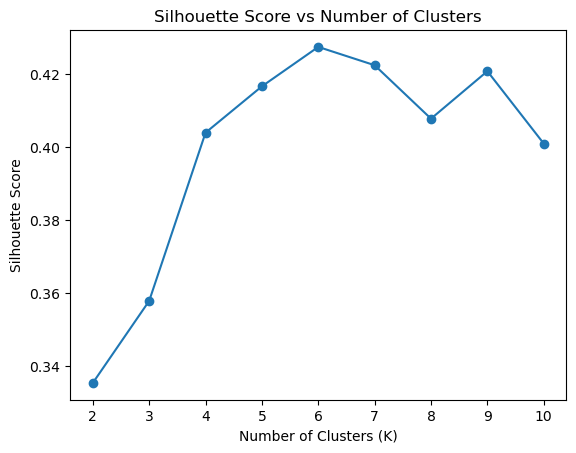

In [48]:
plt.figure()
plt.plot(Ks,sil_scores, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

## Elbow Method (Inertia vs K)

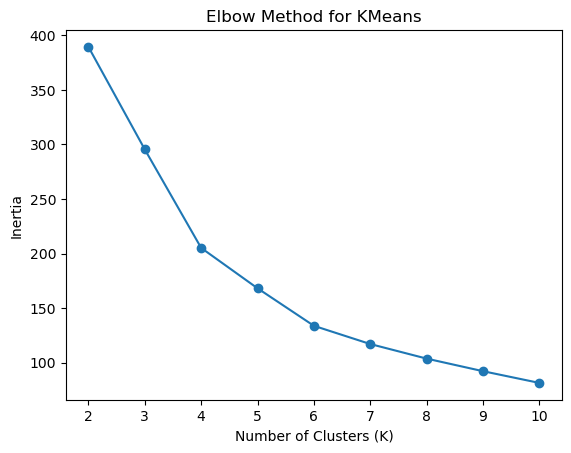

In [51]:
plt.figure()
plt.plot(Ks, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


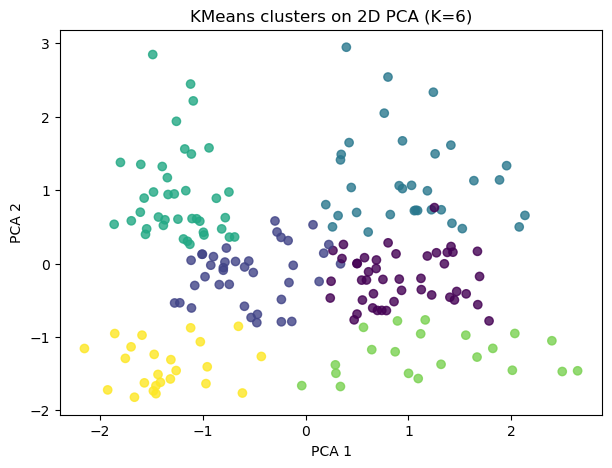

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,56.33,54.27,49.07
1,26.68,57.58,47.79
2,41.94,88.94,16.97
3,32.69,86.54,82.13
4,45.52,26.29,19.38
5,25.25,25.83,76.92


In [55]:
# Fit final KMeans using selected best_k (from silhouette)
kmeans_final = KMeans(n_clusters=best_k, random_state=53, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, alpha=0.8)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"KMeans clusters on 2D PCA (K={best_k})")
plt.show()

profile_kmeans = df.copy()   
profile_kmeans["Cluster"] = kmeans_labels
display(profile_kmeans.groupby("Cluster").mean().round(2))

# =========================================================
# Section (C): AgglomerativeClustering
# =========================================================

In [57]:
linkages = ["single", "complete", "average", "ward"]
agg_rows = []

K = best_k  # use the same K chosen above for fair comparison

for link in linkages:
    agg = AgglomerativeClustering(n_clusters=K, linkage=link)
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    agg_rows.append({"Linkage": link, "K": K, "Silhouette": sil})

agg_results = pd.DataFrame(agg_rows).sort_values("Silhouette", ascending=False)
display(agg_results)

best_linkage = agg_results.iloc[0]["Linkage"]
print(f"Best linkage by silhouette: {best_linkage}")

,Linkage,K,Silhouette
3,ward,6,0.420117
2,average,6,0.389573
1,complete,6,0.374561
0,single,6,-0.042750


Best linkage by silhouette: ward


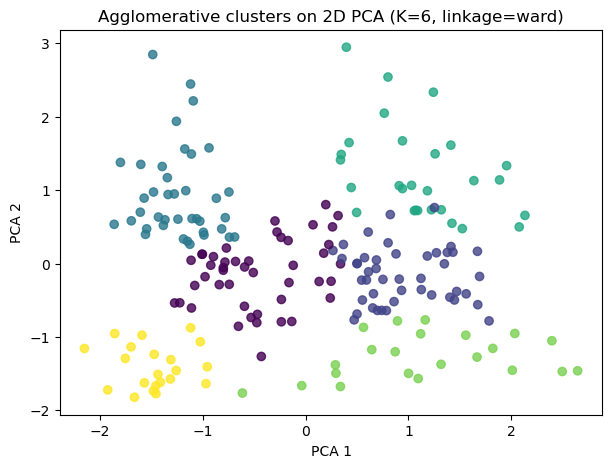

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,27.38,57.51,45.84
1,56.40,55.29,48.36
2,32.69,86.54,82.13
3,43.89,91.29,16.68
4,44.32,25.77,20.27
5,24.81,25.62,80.24


In [61]:
# Fit best Agglomerative model and visualize on PCA
agg_best = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage)
agg_labels = agg_best.fit_predict(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=agg_labels, alpha=0.8)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title(f"Agglomerative clusters on 2D PCA (K={best_k}, linkage={best_linkage})")
plt.show()

# (Bonus) Profiling
profile_agg =df.copy()  
profile_agg["Cluster"] = agg_labels
display(profile_agg.groupby("Cluster").mean().round(2))

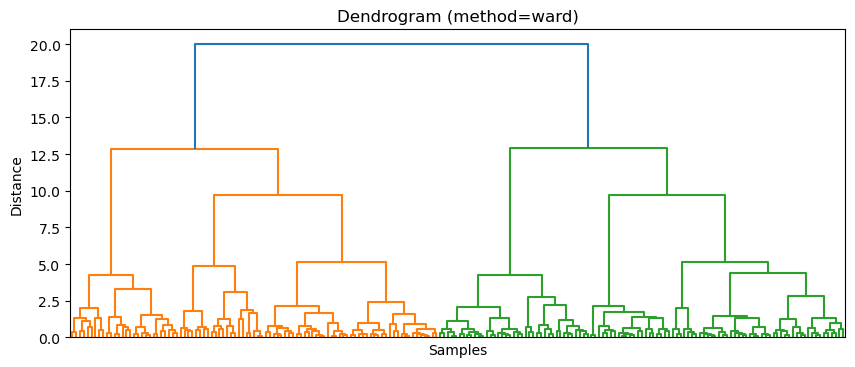

In [84]:
# =========================
# Dendrogram (Hierarchical clustering structure)
# =========================
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt


Z = linkage(X_scaled, method=best_linkage if 'best_linkage' in globals() else 'ward')

plt.figure(figsize=(10,4))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title(f"Dendrogram (method={best_linkage if 'best_linkage' in globals() else 'ward'})")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# =========================================================
# Section (D): DBSCAN
# =========================================================

In [65]:
eps_values = [0.2, 0.4, 0.6, 0.8, 1.0]
min_samples_values = [3, 5, 10]

results = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)

        # Identify noise
        noise_ratio = np.sum(labels == -1) / len(labels)

        # Number of clusters (exclude noise)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Silhouette only on non-noise points
        if n_clusters > 1 and np.sum(labels != -1) > 1:
            sil = silhouette_score(
                X_scaled[labels != -1],
                labels[labels != -1]
            )
        else:
            sil = np.nan

        results.append({
            "eps": eps,
            "min_samples": ms,
            "Clusters": n_clusters,
            "Noise Ratio": noise_ratio,
            "Silhouette": sil
        })

In [67]:
results_df = pd.DataFrame(results)
display(results_df)

# Pick best DBSCAN setting by highest silhouette (ignoring NaN)
best_db = results_df.dropna(subset=["Silhouette"]).sort_values("Silhouette", ascending=False).head(1)
if len(best_db) == 0:
    print("No DBSCAN setting produced >1 cluster with enough non-noise points for silhouette.")
else:
    best_eps = float(best_db.iloc[0]["eps"])
    best_ms  = int(best_db.iloc[0]["min_samples"])
    print("Best DBSCAN by silhouette:")
    display(best_db)

,eps,min_samples,Clusters,Noise Ratio,Silhouette
0,0.2,3,11,0.805,0.645880
1,0.2,5,1,0.975,NaN
2,0.2,10,0,1.000,NaN
3,0.4,3,10,0.295,0.442575
4,0.4,5,6,0.490,0.519023
5,0.4,10,2,0.850,0.766073
6,0.6,3,3,0.070,0.214881
7,0.6,5,2,0.140,0.273047
8,0.6,10,4,0.330,0.529589
9,0.8,3,1,0.015,NaN


Best DBSCAN by silhouette:


,eps,min_samples,Clusters,Noise Ratio,Silhouette
5,0.4,10,2,0.85,0.766073


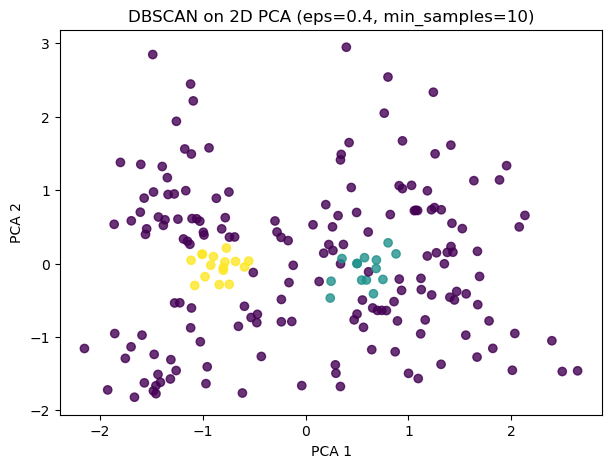

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,48.14,57.57,46.71
1,22.06,60.56,50.12


In [72]:
if 'best_eps' in globals():
    db_best = DBSCAN(eps=best_eps, min_samples=best_ms)
    db_labels = db_best.fit_predict(X_scaled)

    plt.figure(figsize=(7,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels, alpha=0.8)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"DBSCAN on 2D PCA (eps={best_eps}, min_samples={best_ms})")
    plt.show()

    prof_db = df.copy()  
    prof_db["Cluster"] = db_labels

    display(prof_db[prof_db["Cluster"] != -1].groupby("Cluster").mean().round(2))

# =========================
#  Silhouette plot
# =========================

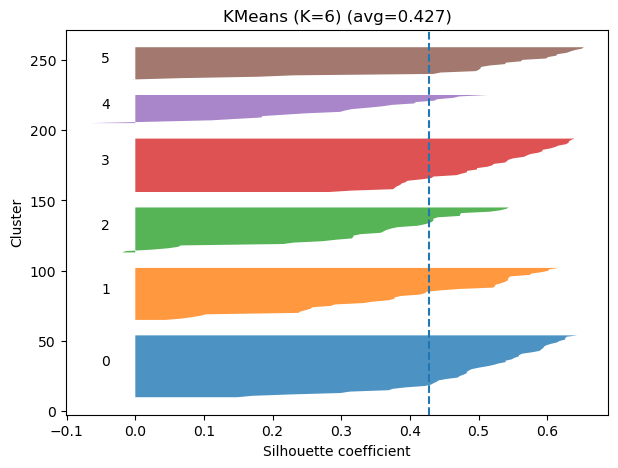

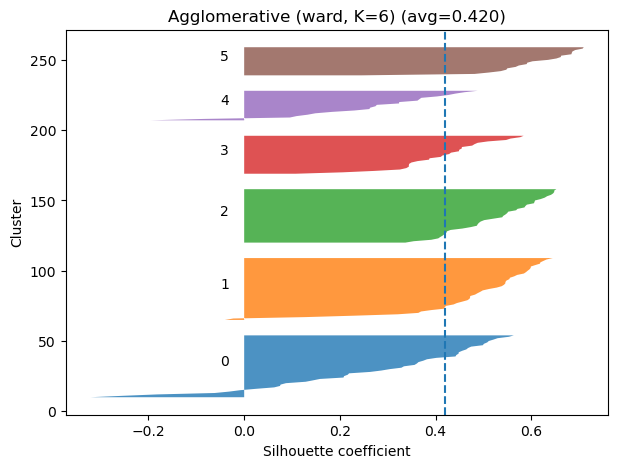

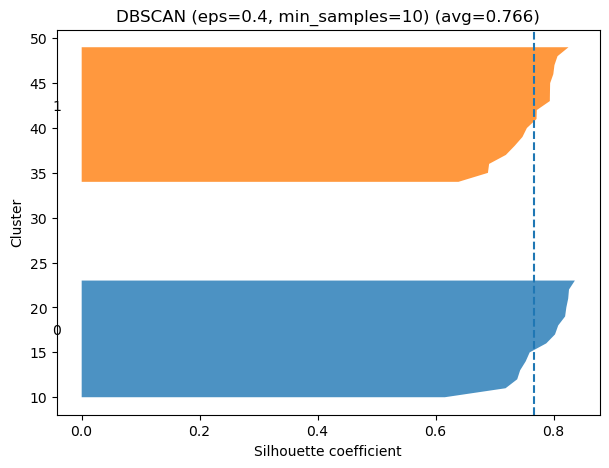

In [76]:
from sklearn.metrics import silhouette_samples
import numpy as np
import matplotlib.pyplot as plt

def plot_silhouette(X, labels, title="Silhouette plot"):
    # For DBSCAN: optionally exclude noise (-1)
    mask = labels != -1
    uniq = np.unique(labels[mask] if np.any(mask) else labels)

    # Need at least 2 clusters
    if len(uniq) < 2:
        print(f"{title}: not enough clusters to plot silhouette.")
        return

    X_use = X[mask] if np.any(mask) else X
    labels_use = labels[mask] if np.any(mask) else labels

    sil_vals = silhouette_samples(X_use, labels_use)
    y_lower = 10

    plt.figure(figsize=(7,5))
    for c in np.unique(labels_use):
        c_sil = np.sort(sil_vals[labels_use == c])
        y_upper = y_lower + len(c_sil)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, alpha=0.8)
        plt.text(-0.05, (y_lower + y_upper) / 2, str(c))
        y_lower = y_upper + 10

    avg = np.mean(sil_vals)
    plt.axvline(x=avg, linestyle="--")
    plt.xlabel("Silhouette coefficient")
    plt.ylabel("Cluster")
    plt.title(f"{title} (avg={avg:.3f})")
    plt.show()

# KMeans
if 'kmeans_labels' in globals():
    plot_silhouette(X_scaled, kmeans_labels, title=f"KMeans (K={best_k})")

# Agglomerative
if 'agg_labels' in globals():
    plot_silhouette(X_scaled, agg_labels, title=f"Agglomerative ({best_linkage}, K={best_k})")

# DBSCAN (noise excluded automatically)
if 'db_labels' in globals():
    plot_silhouette(X_scaled, db_labels, title=f"DBSCAN (eps={best_eps}, min_samples={best_ms})")

# =========================
#  3D visualization on ORIGINAL scaled space 
# =========================

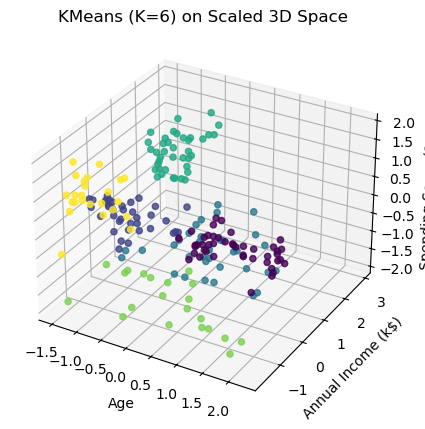

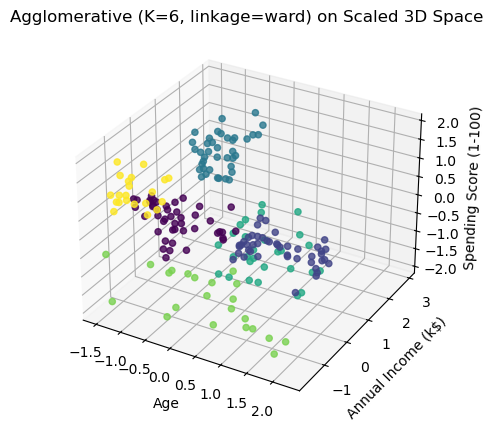

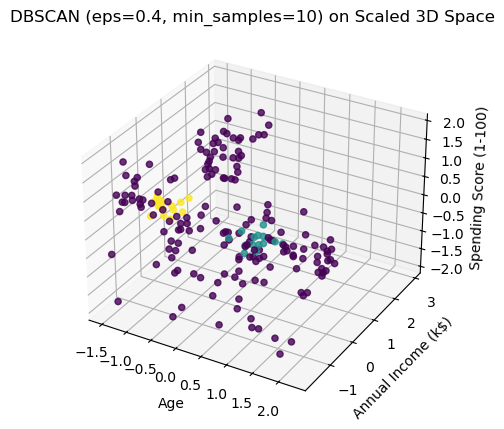

In [82]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

feature_names = list(df.columns)  

def plot_3d_scaled(Xs, labels, title, feat_names):
    if Xs.shape[1] != 3:
        print(f"Skip 3D plot: X_scaled has {Xs.shape[1]} features, needs exactly 3.")
        return
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(Xs[:, 0], Xs[:, 1], Xs[:, 2], c=labels, alpha=0.8)
    ax.set_xlabel(feat_names[0])
    ax.set_ylabel(feat_names[1])
    ax.set_zlabel(feat_names[2])
    ax.set_title(title)
    plt.show()

# KMeans 3D (best_k)
if 'kmeans_labels' in globals():
    plot_3d_scaled(X_scaled, kmeans_labels, f'KMeans (K={best_k}) on Scaled 3D Space', feature_names)

# Agglomerative 3D (best_linkage, best_k)
if 'agg_labels' in globals():
    plot_3d_scaled(X_scaled, agg_labels, f'Agglomerative (K={best_k}, linkage={best_linkage}) on Scaled 3D Space', feature_names)

# DBSCAN 3D (best_eps, best_ms)
if 'db_labels' in globals():
    plot_3d_scaled(X_scaled, db_labels, f'DBSCAN (eps={best_eps}, min_samples={best_ms}) on Scaled 3D Space', feature_names)
else:
    print('DBSCAN: best setting not available (no valid silhouette or not selected).')